<a href="https://colab.research.google.com/github/franciscosrcoelho-coder/Google-Colab/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

np.random.seed(123)
tf.random.set_seed(123)

In [2]:
!pip install -U scikit-learn

In [3]:
from sklearn.metrics import mean_absolute_percentage_error

In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error, \
  mean_absolute_error, r2_score, mean_squared_error

In [5]:
url = 'https://raw.githubusercontent.com/franciscosrcoelho-coder/Google-Colab/refs/heads/main/Data%20Science%20Applications%20Project%20Data.csv'
df = pd.read_csv(url)

In [6]:
# add the date attribute starting from Jan 2000, with a monthly frequency
df['year_month'] = pd.date_range(start='1/2016', end='4/2026', freq='M',
                                    inclusive='both')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        123 non-null    object        
 1   Consumption  123 non-null    int64         
 2   year_month   123 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ KB


In [7]:
df=df.drop('Month',axis=1)

In [8]:
df.set_index('year_month', inplace=True)

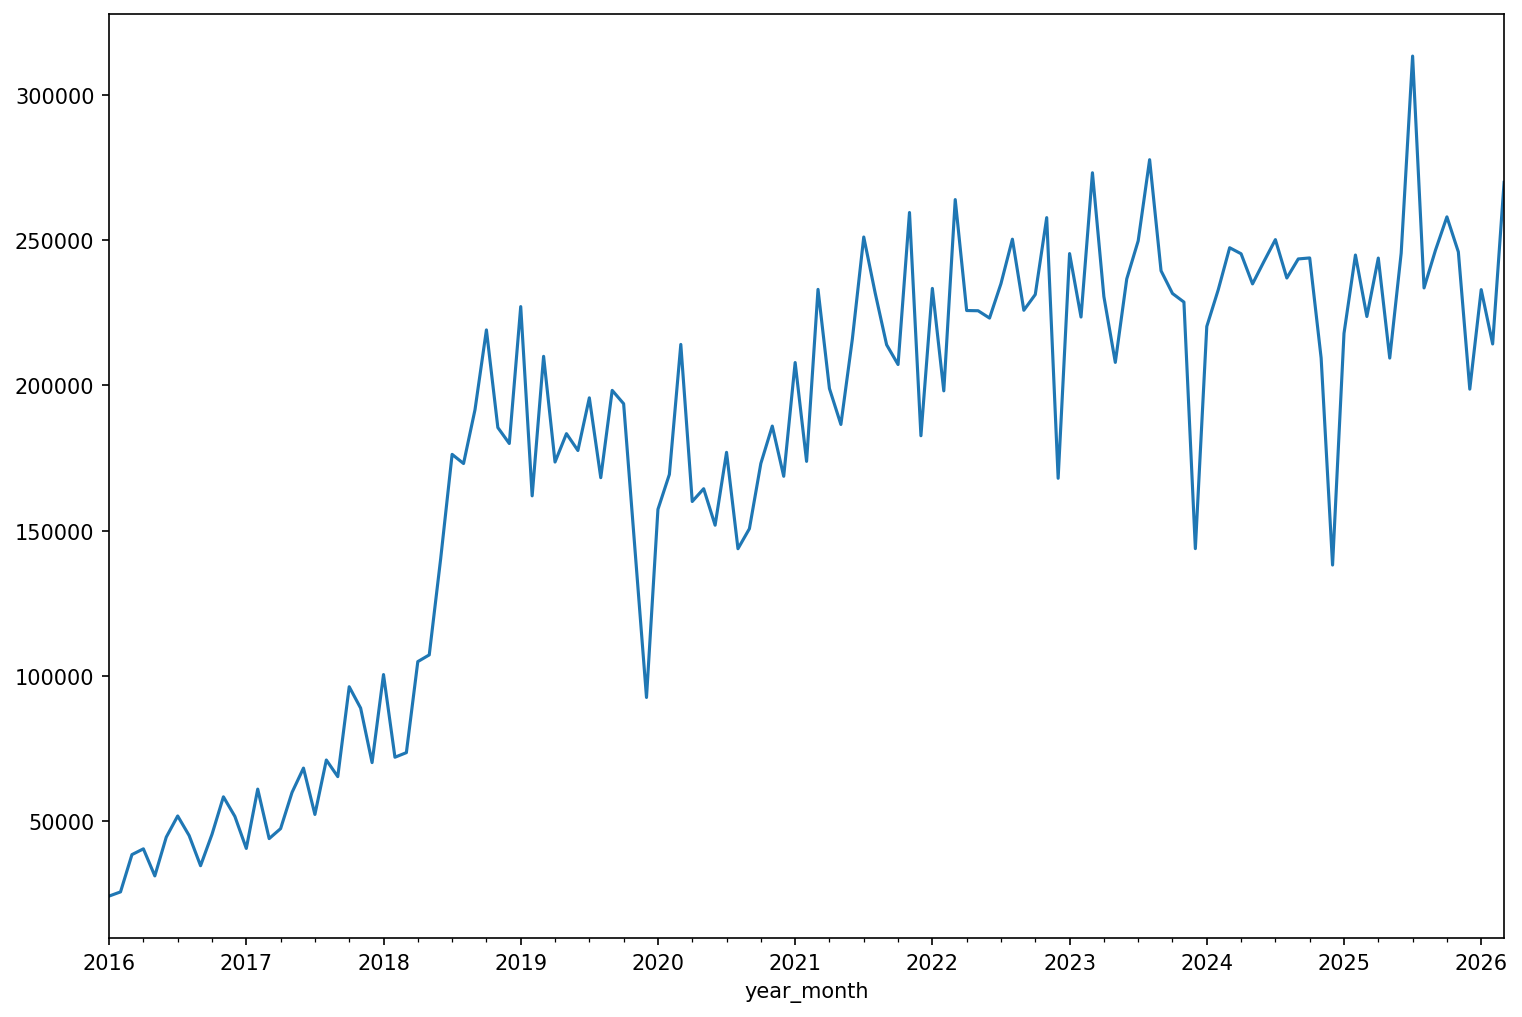

In [9]:
plt.figure(figsize=(12,8),dpi=150)
df['Consumption'].plot();

In [10]:
df.head()

,Consumption
year_month,
2016-01-31,24273
2016-02-29,25715
2016-03-31,38543
2016-04-30,40524
2016-05-31,31222


In [11]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [12]:
# boolean series to index df rows
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [13]:
df['DiffConsumption'] = df['Consumption'].diff()

In [14]:
# Make supervised dataset
series = df['DiffConsumption'].dropna().to_numpy()

T = 10
X = []
Y = []
for t in range(len(series) - T):
  x = series[t:t+T]
  X.append(x)
  y = series[t+T]
  Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (112, 10) Y.shape (112,)


In [15]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:]

# **ANN**

In [16]:
# Basic ANN
i = Input(shape=(T,))
x = Dense(32, activation='relu')(i)
x = Dense(1)(x)
model = Model(i, x)

In [17]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [18]:
r = model.fit(
  Xtrain,
  Ytrain,
  epochs=150,
  validation_data=(Xtest, Ytest)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 1807085952.0000 - val_loss: 2981516032.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 1718155520.0000 - val_loss: 2904697600.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1646108672.0000 - val_loss: 2835718656.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1581582208.0000 - val_loss: 2773393152.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1523523072.0000 - val_loss: 2716752128.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1471337216.0000 - val_loss: 2665336064.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1424812160.0000 - val_loss: 2618268416.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1382910720.0000 - val_loss: 2575045376.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1345151104.0000 - val_loss: 2534892288.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1310843776.0000 - val_l

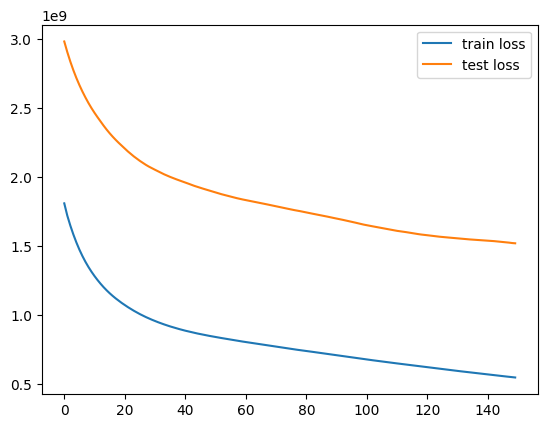

In [19]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [20]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [21]:
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [22]:
# Store diff predictions
df.loc[train_idx, 'Diff ANN Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff ANN Test Prediction'] = Ptest

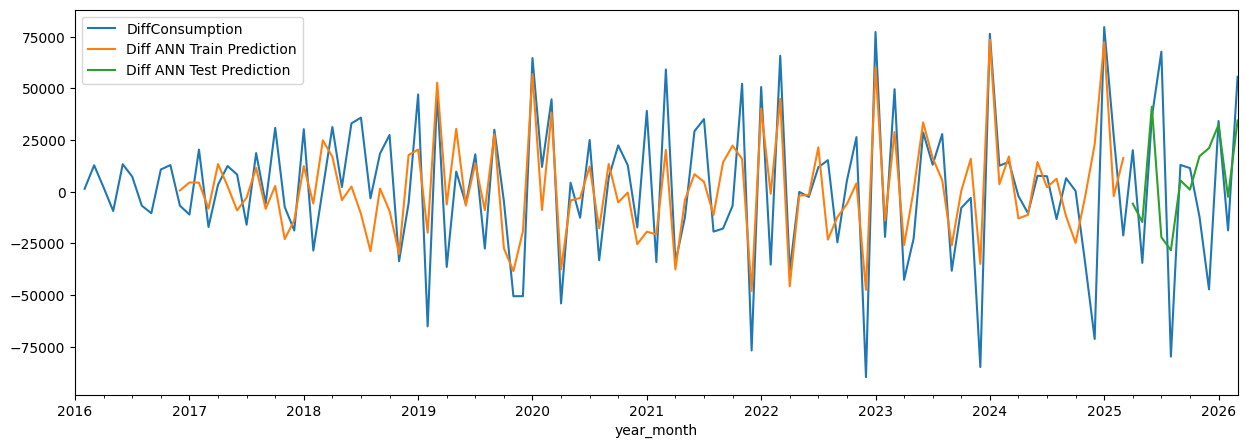

In [23]:
cols = ['DiffConsumption',
        'Diff ANN Train Prediction',
        'Diff ANN Test Prediction']
df[cols].plot(figsize=(15, 5));

In [24]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [25]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [26]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

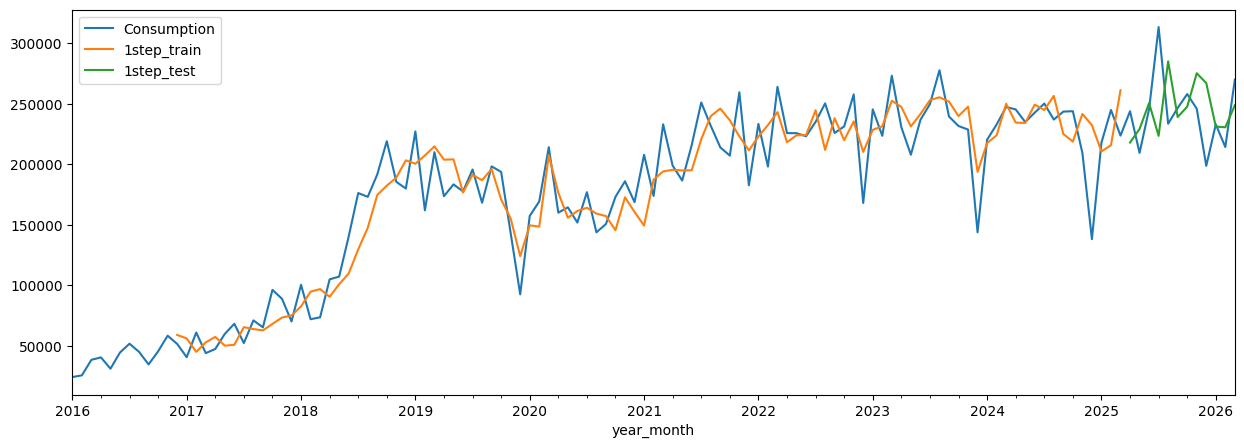

In [27]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [28]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [29]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

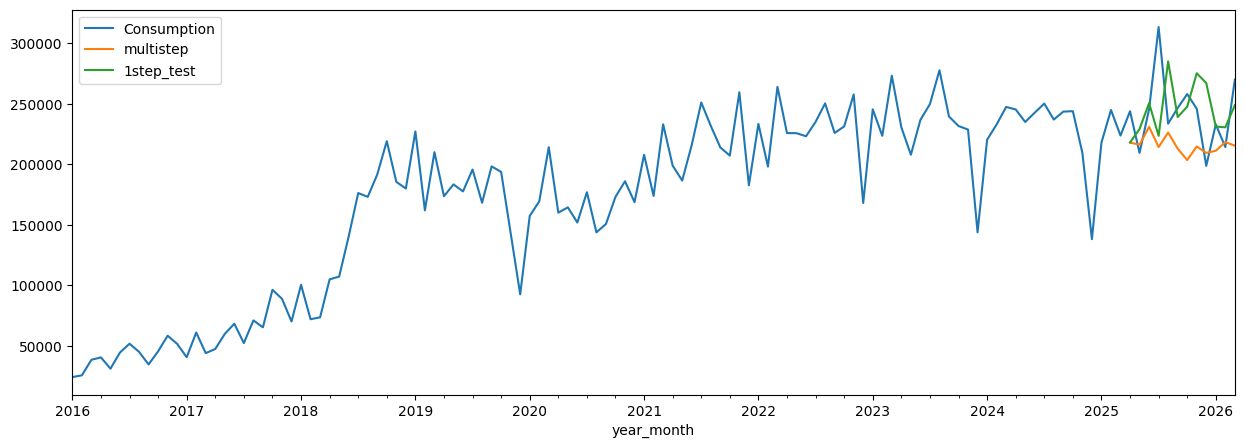

In [30]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [31]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10) Y.shape (101, 12)


In [32]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [33]:
# Basic ANN
i = Input(shape=(Tx,))
x = Dense(32, activation='relu')(i)
x = Dense(Ty)(x)
model = Model(i, x)

In [34]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [35]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=150,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 1732287232.0000 - val_loss: 2877995008.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1677591680.0000 - val_loss: 2814672384.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1630797440.0000 - val_loss: 2755430400.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1587195136.0000 - val_loss: 2699450112.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1546398976.0000 - val_loss: 2645478144.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1508191744.0000 - val_loss: 2593782016.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1472335488.0000 - val_loss: 2544818176.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1438878208.0000 - val_loss: 2498836736.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1407751296.0000 - val_loss: 2457027584.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1378690816.0000 - val_l

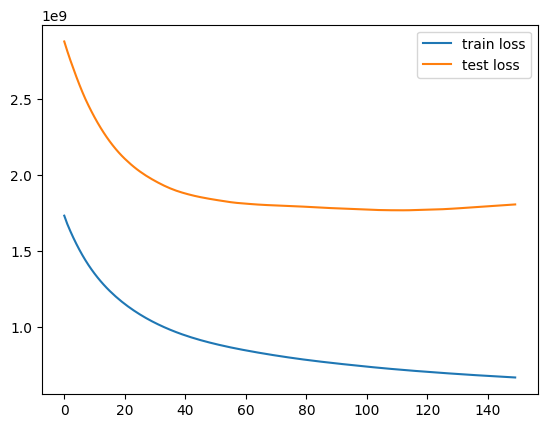

In [36]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [37]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [38]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [39]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

In [40]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

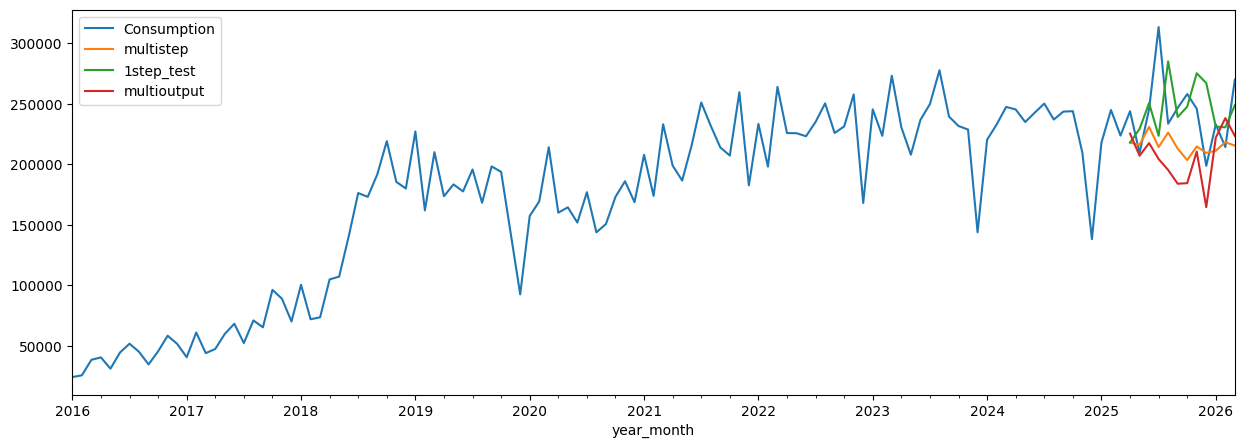

In [41]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [42]:
# MAPE
test_log_pass = df.iloc[-Ntest:]['Consumption']
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)

multi-step MAPE: 0.1156020220465711
multi-output MAPE: 0.15810829437763038


# **CNN**

In [43]:
df.head()

,Consumption,DiffConsumption,Diff ANN Train Prediction,Diff ANN Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,multioutput
year_month,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN


In [44]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],
      dtype='object')

In [45]:
df=df.drop(['Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],axis=1)

In [46]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.models import Model

In [47]:
# CNN
i = Input(shape=(T, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

In [48]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 8, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [50]:
# CNN
i = Input(shape=(T, 1), dtype=tf.float32)
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

model.compile(
  loss='mse',
  optimizer='adam',
)

Xtrain_cnn = Xtrain.reshape(-1, T, 1).astype(np.float32)
Ytrain_cnn = Ytrain.astype(np.float32)
Xtest_cnn = Xtest.reshape(-1, T, 1).astype(np.float32)
Ytest_cnn = Ytest.astype(np.float32)

r = model.fit(
  Xtrain_cnn,
  Ytrain_cnn,
  epochs=100,
  validation_data=(Xtest_cnn, Ytest_cnn)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 1210508160.0000 - val_loss: 1669769216.0000
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1156372864.0000 - val_loss: 1670014464.0000
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1137454592.0000 - val_loss: 1665443712.0000
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1119340416.0000 - val_loss: 1646064512.0000
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1100131072.0000 - val_loss: 1630781440.0000
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1083177600.0000 - val_loss: 1614339200.0000
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1066827456.0000 - val_loss: 1599522432.0000
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1049571584.0000 - val_loss: 1585783424.0000
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1030924928.0000 - val_loss: 1568685952.0000
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1011952832.0000 - val_l

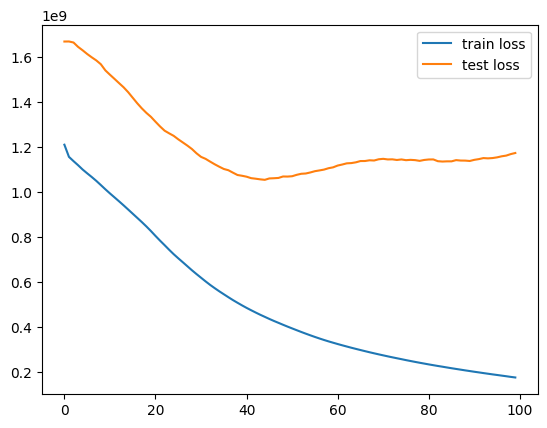

In [51]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [52]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [53]:
Ptrain = model.predict(Xtrain_cnn).flatten()
Ptest = model.predict(Xtest_cnn).flatten()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [54]:
# Store diff predictions
df.loc[train_idx, 'Diff Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff Test Prediction'] = Ptest

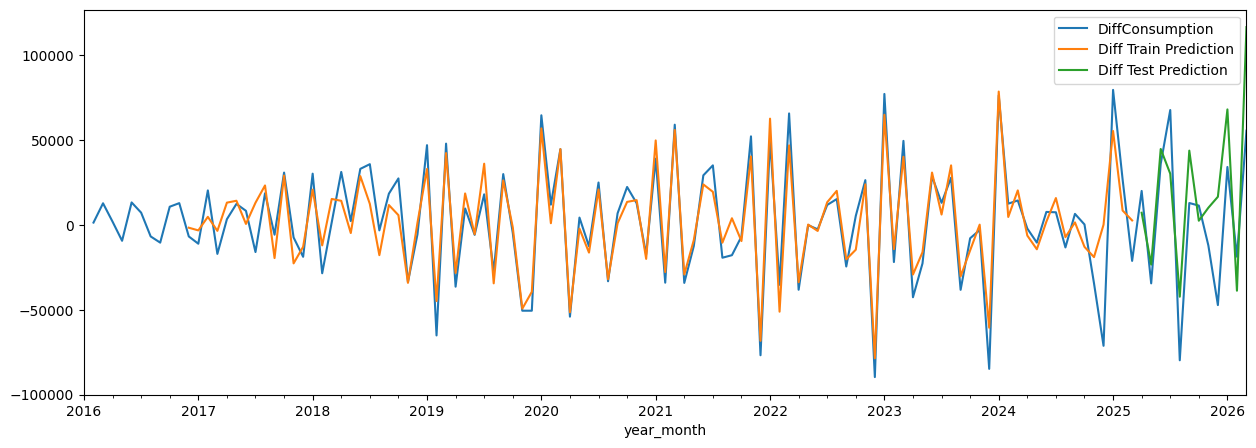

In [55]:
cols = ['DiffConsumption',
        'Diff Train Prediction',
        'Diff Test Prediction']
df[cols].plot(figsize=(15, 5));

In [56]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [57]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [58]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

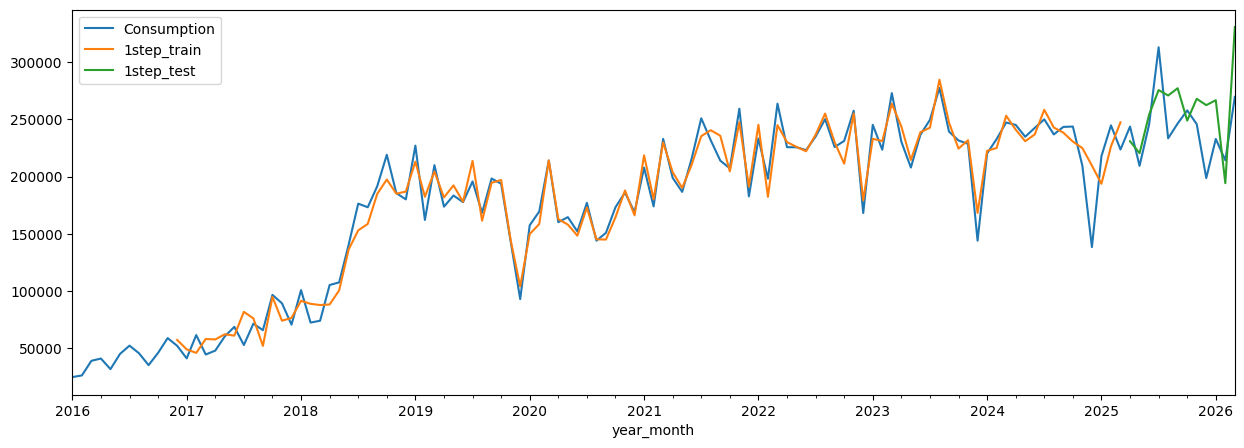

In [59]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [60]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1, 1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [61]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

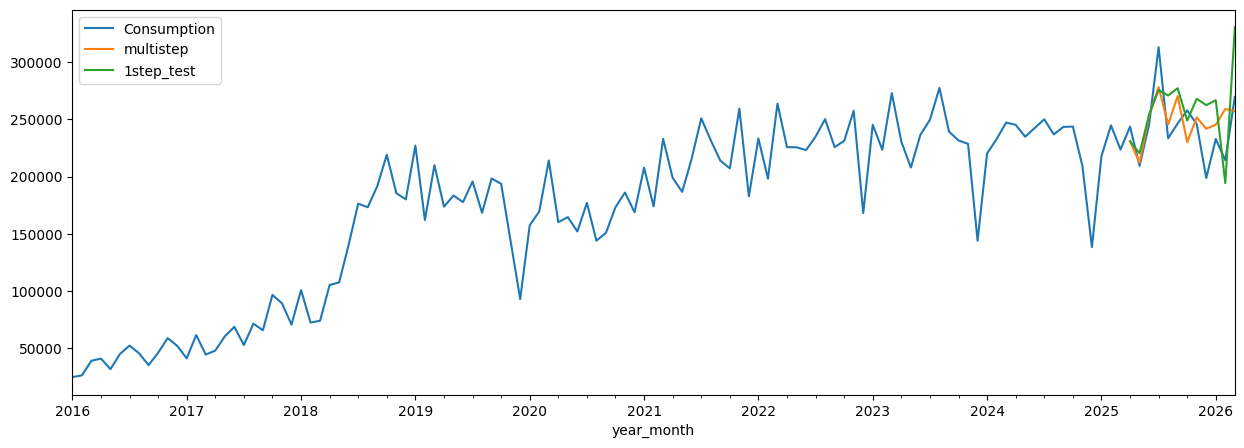

In [62]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [63]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx, 1)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10, 1) Y.shape (101, 12)


In [64]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [65]:
# CNN
i = Input(shape=(Tx, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(Ty)(x)
model = Model(i, x)

In [66]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [67]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=200,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 1356598528.0000 - val_loss: 1510853248.0000
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1328559616.0000 - val_loss: 1577499648.0000
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1310616832.0000 - val_loss: 1642995712.0000
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 1298217344.0000 - val_loss: 1703286656.0000
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1289399552.0000 - val_loss: 1757863936.0000
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1283110016.0000 - val_loss: 1798818176.0000
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1278294016.0000 - val_loss: 1830164480.0000
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1273949056.0000 - val_loss: 1851888128.0000
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1270175104.0000 - val_loss: 1867176576.0000
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1266958720.0000 - val_

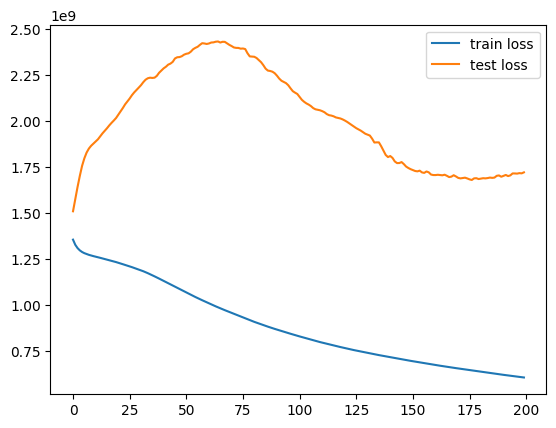

In [68]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [69]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [70]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [71]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

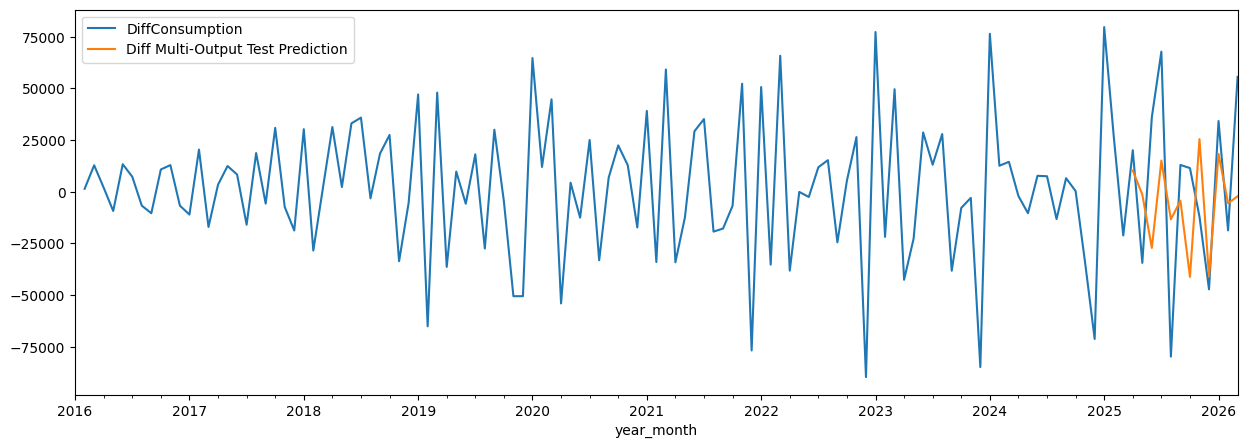

In [72]:
df.loc[test_idx, 'Diff Multi-Output Test Prediction'] = Ptest
cols = ['DiffConsumption', 'Diff Multi-Output Test Prediction']
df[cols].plot(figsize=(15, 5));

In [73]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

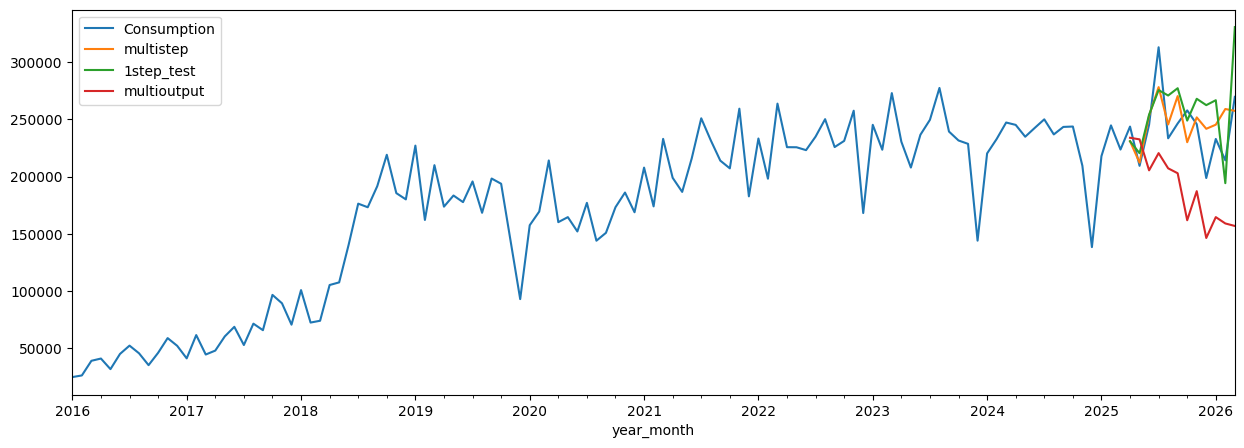

In [74]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [75]:
# MAPE
test_log_pass = df.iloc[-Ntest:]['Consumption']
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)

multi-step MAPE: 0.08478864494735604
multi-output MAPE: 0.22897181986104


# **RNN**

In [76]:
df.head()

,Consumption,DiffConsumption,Diff Train Prediction,Diff Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,Diff Multi-Output Test Prediction,multioutput
year_month,,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN,NaN


In [77]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff Train Prediction',
       'Diff Test Prediction', 'ShiftConsumption', '1step_train', '1step_test',
       'multistep', 'Diff Multi-Output Test Prediction', 'multioutput'],
      dtype='object')

In [78]:
df=df.drop(['Diff Train Prediction',
       'Diff Test Prediction', 'ShiftConsumption', '1step_train', '1step_test',
       'multistep', 'Diff Multi-Output Test Prediction', 'multioutput'],axis=1)

In [79]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, LSTM, GRU
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint